# Baseline Model — Custom CNN (No Augmentation)

## Purpose

This notebook trains a **baseline image classification model** using a simple custom Convolutional Neural Network (CNN) built from scratch. 

The goal is to establish a reference point for a from-scratch CNN, which can then be compared against the transfer learning approach in `02_baseline_model_MobileNetV2.ipynb`.

The preprocessing pipeline is imported directly from `src/preprocessing.py`, keeping this notebook focused purely on model architecture, training, and evaluation.

---

## What this notebook covers

| Step | Description |
|------|-------------|
| 1. Setup & Imports | Libraries and dataset loading via `src.preprocessing` |
| 2. Load Data | Call `get_datasets()` and verify split sizes |
| 3. Build Model | Custom CNN architecture built from scratch |
| 4. Compile | Loss function, optimiser, and evaluation metrics |
| 5. Train | `model.fit()` with early stopping and model checkpointing |
| 6. Evaluate | Compare best and last saved models on the test set |
| 7. Training Curves | Accuracy and loss plots over epochs |
| 8. Misclassified Images | Visualise images the model got wrong |

---

## What is a custom CNN?

A custom CNN is a convolutional neural network designed and trained from scratch without using any pretrained weights. It learns visual features — edges, textures, shapes — directly from the campus dataset rather than borrowing features from ImageNet.

Training from scratch is harder with a small dataset (~1,253 images) and typically achieves lower accuracy than transfer learning. However it serves as an important comparison point to quantify how much value the pretrained MobileNetV2 weights add.

## 1. Setup & Imports

This section imports all required libraries and loads the preprocessing pipeline from `src/preprocessing.py`.

### Path setup

Notebooks run from the `notebooks/` directory, but `src/preprocessing.py` lives one level up in the project root. Adding the project root to `sys.path` allows Python to find the `src` package when we write `from src.preprocessing import ...`.

### Constants

All image constants (`IMAGE_SIZE`, `BATCH_SIZE`, `RANDOM_SEED`) are defined in `src/preprocessing.py` and imported here to keep everything consistent across notebooks — there is no need to redefine them.

In [2]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
# tf.config.set_visible_devices([], 'GPU')

# Add the project root to sys.path so 'from src.preprocessing import ...' works
sys.path.insert(0, str(Path().resolve().parent))

from src.preprocessing import (
    get_datasets,
    IMAGE_SIZE,
    BATCH_SIZE,
    RANDOM_SEED,
)

print("Image size:        ", IMAGE_SIZE)
print("Batch size:        ", BATCH_SIZE)
print("Random seed:       ", RANDOM_SEED)

Image size:         (224, 224)
Batch size:         32
Random seed:        42


## 2. Load Data

This section calls `get_datasets()` from `src/preprocessing.py` which runs the full pipeline — scanning the dataset folder, splitting into train/val/test, and building `tf.data` pipelines — in a single call.

The number of batches per split is printed as a sanity check to confirm the data loaded correctly before building the model.

In [4]:
train_ds, val_ds, test_ds, class_names = get_datasets()

NUM_CLASSES = len(class_names)

print(f"Classes ({NUM_CLASSES}):       {class_names}")
print(f"Train batches:      {len(train_ds)}")
print(f"Validation batches: {len(val_ds)}")
print(f"Test batches:       {len(test_ds)}")

Classes (8):       ['2', '3', '4', '5', '7', '8', '9', '10']
Train batches:      27
Validation batches: 6
Test batches:       6


## 3. Build Model

The model consists of **3 convolutional blocks** followed by a classification head. Each block progressively extracts more complex visual features while reducing the spatial dimensions.

### Architecture

| Block | Layers | Output Shape | Purpose |
|-------|--------|-------------|---------|
| Block 1 | Conv2D(32) → ReLU → MaxPool | (112, 112, 32) | Low-level features — edges, textures |
| Block 2 | Conv2D(64) → ReLU → MaxPool | (56, 56, 64) | Mid-level features — corners, patterns |
| Block 3 | Conv2D(128) → ReLU → MaxPool | (28, 28, 128) | High-level features — shapes, structures |
| Head | GlobalAveragePooling2D → Dropout(0.5) → Dense(8, softmax) | (8,) | Classification |

### Design decisions

- **Doubling filters** (32 → 64 → 128) — standard pattern where each block learns increasingly complex features
- **3×3 kernels** — the most common kernel size, captures local spatial patterns effectively
- **MaxPool(2×2)** — halves the spatial dimensions after each block, reducing computation and overfitting
- **GlobalAveragePooling2D** — reduces the final feature maps to a compact vector with far fewer parameters than Flatten
- **Dropout(0.5)** — higher than MobileNetV2 (0.2) because this model trains all weights from scratch and is more prone to overfitting on a small dataset

In [6]:
model = tf.keras.Sequential([

    # Block 1 — detect low-level features (edges, textures)
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(*IMAGE_SIZE, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Block 2 — detect mid-level features (corners, patterns)
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Block 3 — detect high-level features (shapes, structures)
    tf.keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Head — reduce to feature vector and classify
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.5),  # Higher dropout since all weights train from scratch
    tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,280 (368.28 KB)

 Trainable params: 94,280 (368.28 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Compile

**Loss — `sparse_categorical_crossentropy`**
Used for multi-class classification with integer labels (0–7).

**Optimiser — `Adam(learning_rate=1e-3)`**
Adam with the default learning rate.

**Metric — `accuracy`**
Tracks classification accuracy on train and validation sets each epoch.

In [7]:
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["accuracy"]
)

## 5. Train

### Callbacks

**Early stopping**
Monitors `val_loss` after each epoch. If it does not improve for **5 consecutive epochs** (`patience=5`), training stops automatically. `restore_best_weights=True` rolls the model back to the epoch with the lowest `val_loss`.

**ModelCheckpoint — best model**
Saves the model to `models/baseline_cnn_best.keras` every time `val_loss` improves.

**Last model**
After `model.fit()` completes, the final model state is saved to `models/baseline_cnn_last.keras` for comparison with the best checkpoint.

### What to expect

Since all weights are trained from scratch on a small dataset, the model will need more epochs to converge. Overfitting is likely — the training accuracy may climb while validation accuracy plateaus, which is why dropout and early stopping are important here.

In [8]:
MODELS_DIR = Path().resolve().parent / "models"
MODELS_DIR.mkdir(exist_ok=True)

# Stop training early if val_loss does not improve for 5 consecutive epochs
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Save the best model seen during training (lowest val_loss)
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(MODELS_DIR / "baseline_cnn_best.keras"),
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stopping, checkpoint]
)

# Save the final model state at the end of training
model.save(MODELS_DIR / "baseline_cnn_last.keras")
print("Last model saved to:", MODELS_DIR / "baseline_cnn_last.keras")

Epoch 1/30


2026-04-12 17:34:49.994288: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1236 - loss: 2.0779
Epoch 1: val_loss improved from None to 2.03525, saving model to /Users/adamnajajreh/ltu/2. semester/DL/Capstone/models/baseline_cnn_best.keras

Epoch 1: finished saving model to /Users/adamnajajreh/ltu/2. semester/DL/Capstone/models/baseline_cnn_best.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.1529 - loss: 2.0677 - val_accuracy: 0.2065 - val_loss: 2.0352
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2171 - loss: 2.0174
Epoch 2: val_loss improved from 2.03525 to 1.95894, saving model to /Users/adamnajajreh/ltu/2. semester/DL/Capstone/models/baseline_cnn_best.keras

Epoch 2: finished saving model to /Users/adamnajajreh/ltu/2. semester/DL/Capstone/models/baseline_cnn_best.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.2147 - loss: 2.0136 - val_accuracy: 0.2717 - val_loss: 1.9589
Epoch 3/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2537 - loss: 1.9591
Epoch 3: val_

## 6. Evaluate

This section evaluates both saved models on the **test set** — the held-out split that was never seen during training or validation.

- **Best model** (`baseline_cnn_best.keras`) — saved at the epoch with the lowest `val_loss`
- **Last model** (`baseline_cnn_last.keras`) — saved at the end of training

Comparing the two tells us whether early stopping and `restore_best_weights` made a meaningful difference. Test accuracy is the final unbiased measure of how well the model generalises to new images.

In [9]:
saved_models = {
    "Best  (lowest val_loss)": MODELS_DIR / "baseline_cnn_best.keras",
    "Last  (end of training)": MODELS_DIR / "baseline_cnn_last.keras",
}

print(f"{'Model':<30} {'Loss':>8}  {'Accuracy':>10}")
print("-" * 52)

for label, model_path in saved_models.items():
    loaded_model = tf.keras.models.load_model(model_path)
    loss, acc = loaded_model.evaluate(test_ds, verbose=0)
    print(f"{label:<30} {loss:>8.4f}  {acc * 100:>9.2f}%")

Model                              Loss    Accuracy
----------------------------------------------------
Best  (lowest val_loss)          0.7072      81.52%
Last  (end of training)          0.7072      81.52%


## 7. Training Curves

Plotting accuracy and loss over epochs shows how the model learned and whether it overfit.

**Accuracy plot** — both train and val accuracy should rise. A growing gap between them indicates overfitting.

**Loss plot** — both train and val loss should fall. A rising val loss while train loss continues to fall is the clearest sign of overfitting — this is exactly what early stopping monitors.

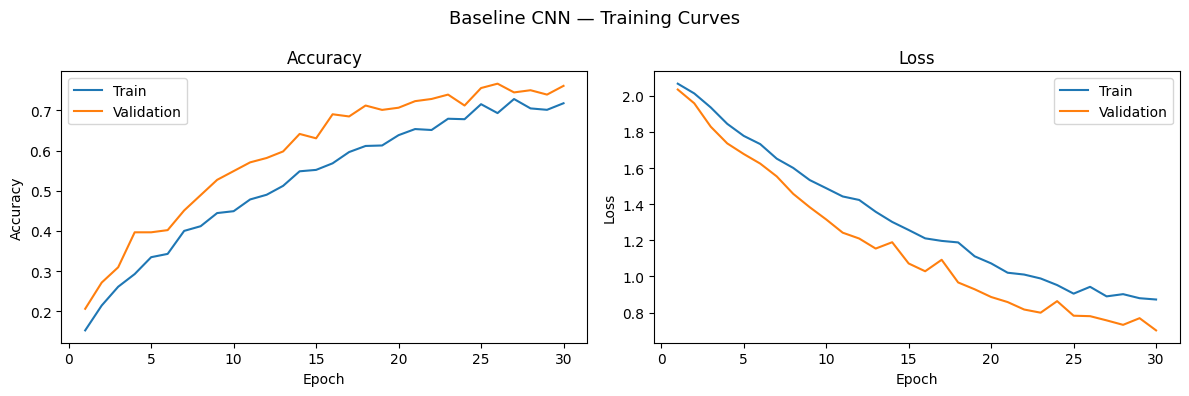

In [10]:
epochs_range = range(1, len(history.history["accuracy"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
ax1.plot(epochs_range, history.history["accuracy"],     label="Train")
ax1.plot(epochs_range, history.history["val_accuracy"], label="Validation")
ax1.set_title("Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()

# Loss
ax2.plot(epochs_range, history.history["loss"],     label="Train")
ax2.plot(epochs_range, history.history["val_loss"], label="Validation")
ax2.set_title("Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()

plt.suptitle("Baseline CNN — Training Curves", fontsize=13)
plt.tight_layout()
plt.show()

## 8. Misclassified Images

Visualising the images the model got wrong helps identify patterns in its mistakes — for example, which buildings are being confused with each other, and whether the errors come from difficult angles, lighting, or visual similarity between classes.

Loading model: baseline_cnn_best


2026-04-12 17:55:26.261864: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Total images:         184
Correctly classified: 150
Misclassified:        34
Accuracy:             81.52%


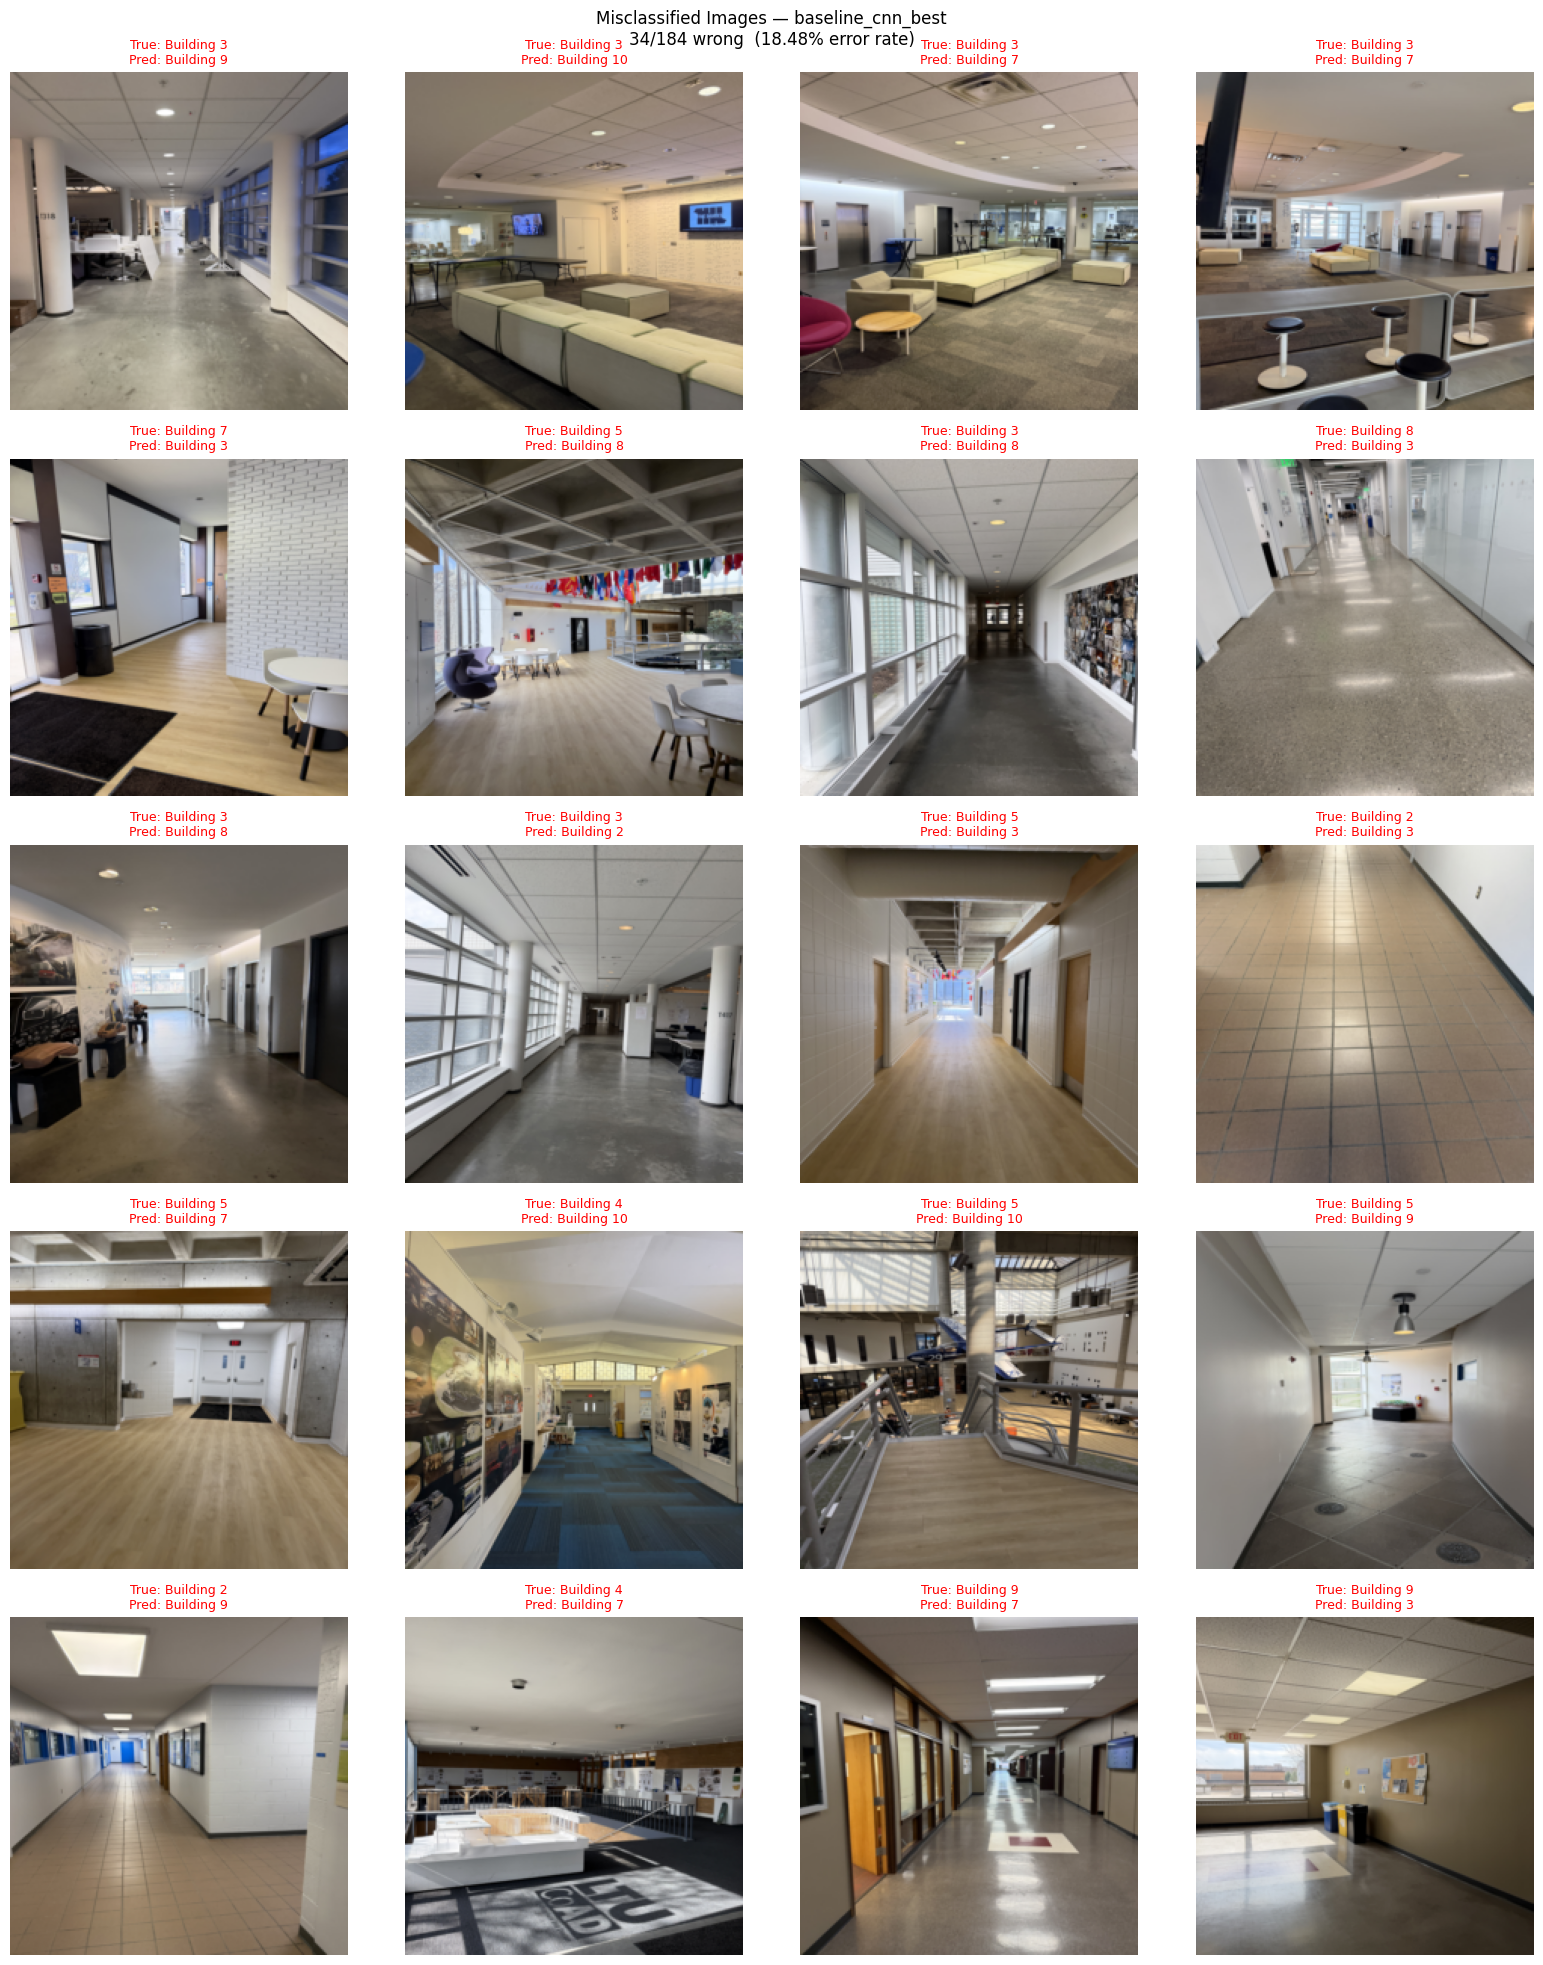

In [12]:
from src.visualize import show_misclassified

show_misclassified("baseline_cnn_best", test_ds, class_names)